# Data-Driven Recovery of Stochastic Generators
## Complete Figure-Generation Pipeline

Run **all cells top-to-bottom**. Figures saved as PDFs in `pub_figs/`.

| Fig | Content | New? |
|-----|---------|------|
| 1 | Recovered vs true (diffusions top, drifts bottom) | |
| 2 | LassoCV regularisation paths | |
| 3 | Stationary density (Fokker-Planck) | |
| 4 | Autocorrelation (DW lag extended to 30 s) | |
| 5 | Theoretical noise scaling | |
| 6 | Empirical endogeneity bias vs T | NEW |
| 7 | CLT convergence rates | NEW |
| 8 | Hyperparameter robustness heatmap | NEW |
| 9 | Bias correction -- OLS uncorrected vs LASSO corrected | NEW |

**Runtime:** ~35-55 min on CPU laptop.

In [ ]:
# ── Cell 0: Imports & global parameters ──────────────────────────────────────
import os, warnings, time
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from sklearn.linear_model import LassoCV
from sklearn.model_selection import GroupKFold
from numpy.linalg import lstsq, norm
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)

OUT_DIR = './results'
os.makedirs(OUT_DIR, exist_ok=True)

def savefig(fig, name):
    p = os.path.join(OUT_DIR, name)
    fig.savefig(p, format='pdf', bbox_inches='tight')
    print(f'  saved -> {p}')

# Simulation
DT = 0.002; T = 100.0; N = int(T / DT); R = 120

# Library
DEG = 4; K_DIM = DEG + 1
FEAT = ['$1$', '$x$', '$x^2$', '$x^3$', '$x^4$']
x_eval = np.linspace(-3., 3., 401)

# Kernel defaults
M_CENTRES = 50; H_OU_DW = 0.22; H_MULT = 0.27

# Regression
ALPHA_GRID = np.logspace(-8, -0.5, 60)
CV_SPLITS  = 5; STLS_OU_DW = 0.25; STLS_MULT = 0.30

# Publication style
try:
    plt.style.use('seaborn-v0_8-paper')
except OSError:
    pass

PUB_RC = {
    'font.family': 'serif',
    'font.serif':  ['Times New Roman', 'Times', 'DejaVu Serif'],
    'font.size': 12, 'axes.titlesize': 11, 'axes.labelsize': 11,
    'xtick.labelsize': 9, 'ytick.labelsize': 9, 'legend.fontsize': 9,
    'figure.dpi': 150, 'savefig.dpi': 300,
    'axes.linewidth': 0.8, 'lines.linewidth': 1.8,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
    'text.usetex': False,
}

C_T  = '#1f77b4'   # blue  - true
C_H  = '#d62728'   # red   - recovered
C_SP = '#2ca02c'   # green - spatial kernels
C_TM = '#ff7f0e'   # orange- temporal (biased)
C_RF = '#7f7f7f'   # grey  - reference

print(f'Output: {os.path.abspath(OUT_DIR)}/')
print(f'R={R} trajectories | N={N} steps | dt={DT}')


Output: /content/pub_figs/
R=120 trajectories | N=50000 steps | dt=0.002


In [ ]:
# ── Cell 1: True SDE definitions ─────────────────────────────────────────────
THETA_OU = 1.0; SIGMA0_OU = 0.7; SIGMA0_DW = 0.5

b_ou   = lambda x: -THETA_OU * np.asarray(x, float)
s_ou   = lambda x: np.full_like(np.asarray(x, float), SIGMA0_OU)
b_dw   = lambda x: np.asarray(x, float) - np.asarray(x, float)**3
s_dw   = lambda x: np.full_like(np.asarray(x, float), SIGMA0_DW)
b_mult = lambda x: -2.0 * np.asarray(x, float)
s_mult = lambda x: 0.5 * np.sqrt(1.0 + np.asarray(x, float)**2)

# Ground-truth coefficient vectors  [1, x, x^2, x^3, x^4]
C_B_OU   = np.array([0., -THETA_OU,    0.,  0.,  0.])
C_A_OU   = np.array([SIGMA0_OU**2,     0.,  0.,  0.,  0.])
C_B_DW   = np.array([0.,  1.,          0., -1.,  0.])
C_A_DW   = np.array([SIGMA0_DW**2,     0.,  0.,  0.,  0.])
C_B_MULT = np.array([0., -2.,          0.,  0.,  0.])
C_A_MULT = np.array([0.25, 0.,        0.25, 0.,  0.])

print('SDE definitions ready.')


SDE definitions ready.


In [ ]:
# ── Cell 2: Core algorithms ───────────────────────────────────────────────────

def sim_batch(b_fn, s_fn, R_traj, n_steps=N, dt=DT,
              x0_lo=-3., x0_hi=3., seed=None):
    if seed is not None:
        np.random.seed(seed)
    X = np.empty((R_traj, n_steps + 1))
    X[:, 0] = np.random.uniform(x0_lo, x0_hi, R_traj)
    sqdt = np.sqrt(dt)
    xi   = np.random.randn(n_steps, R_traj)
    for step in range(n_steps):
        xn = X[:, step]
        X[:, step + 1] = xn + b_fn(xn)*dt + s_fn(xn)*sqdt*xi[step]
    return X

def poly(x, deg=DEG):
    x = np.asarray(x, float).ravel()
    return np.column_stack([x**k for k in range(deg + 1)])

def kern(xL, centres, h):
    return np.exp(-0.5 * ((xL[None, :] - centres[:, None]) / h)**2)

def weak_mats(X_batch, centres, h, dt=DT):
    R_b = X_batch.shape[0]; M = len(centres); K = DEG + 1
    A = np.empty((R_b * M, K))
    B = np.empty(R_b * M)
    Q = np.empty(R_b * M)
    for r in range(R_b):
        xL = X_batch[r, :-1]; dx = X_batch[r, 1:] - xL
        Th = poly(xL); Km = kern(xL, centres, h)
        sl = slice(r * M, (r + 1) * M)
        A[sl] = (Km @ Th) * dt
        B[sl] = Km @ dx
        Q[sl] = Km @ (dx**2)
    return A, B, Q, np.repeat(np.arange(R_b), M)

def ols(A, y):
    coef, *_ = lstsq(A, y, rcond=None)
    return coef

def sparse_fit(A, y, traj_id, alpha_grid=ALPHA_GRID,
               n_splits=CV_SPLITS, stls_thr=0.25, max_iter=20):
    norms = norm(A, axis=0); norms[norms < 1e-14] = 1.
    An = A / norms
    cv = list(GroupKFold(n_splits=n_splits).split(An, y, traj_id))
    lasso = LassoCV(alphas=alpha_grid, cv=cv,
                    fit_intercept=False, max_iter=100_000, tol=1e-7)
    lasso.fit(An, y)
    coef_n = lasso.coef_.copy()
    supp = np.where(coef_n != 0)[0]
    if len(supp):
        coef_n[supp] = ols(An[:, supp], y)
    for _ in range(max_iter):
        sc  = coef_n / norms; thr = stls_thr * np.max(np.abs(sc))
        bad = np.abs(sc) < thr
        if not bad.any(): break
        coef_n[bad] = 0.
        supp = np.where(coef_n != 0)[0]
        if not len(supp): break
        coef_n[supp] = ols(An[:, supp], y)
    return coef_n / norms, lasso

def temporal_ols(X_batch, M_win, dt=DT):
    A_lst, B_lst = [], []
    for r in range(X_batch.shape[0]):
        xL = X_batch[r, :-1]; dx = X_batch[r, 1:] - xL
        w  = len(xL) // M_win
        for j in range(M_win):
            sl = slice(j*w, min((j+1)*w, len(xL)))
            A_lst.append(poly(xL[sl]).sum(axis=0) * dt)
            B_lst.append(dx[sl].sum())
    return ols(np.vstack(A_lst), np.array(B_lst))

def run_experiment(b_fn, s_fn, seed, centres, h, stls_thr,
                   n_traj=R, n_steps=N, dt=DT):
    t0 = time.time()
    Xb = sim_batch(b_fn, s_fn, n_traj, n_steps, dt, seed=seed)
    A, B, Q, tid = weak_mats(Xb, centres, h, dt)
    print(f'  sim+mats: {time.time()-t0:.1f}s')

    t0 = time.time()
    coef_b, l_b = sparse_fit(A, B, tid, stls_thr=stls_thr)
    print(f'  drift  LASSO: {time.time()-t0:.1f}s  supp={np.where(coef_b!=0)[0].tolist()}')

    # OLS on raw (uncorrected) Q -- reveals the true ~13% bias in Fig 9
    coef_a_ols_raw = ols(A, Q)

    # LASSO on raw Q (regularised, partial masking of bias)
    coef_a_lasso_raw, _ = sparse_fit(A, Q, tid, stls_thr=stls_thr)

    # Drift-squared bias correction
    Q_corr = Q.copy()
    for r in range(n_traj):
        xL = Xb[r, :-1]
        Km = kern(xL, centres, h)
        bh = poly(xL) @ coef_b
        sl = slice(r * len(centres), (r+1)*len(centres))
        Q_corr[sl] -= (Km @ (bh**2)) * dt**2

    t0 = time.time()
    coef_a, l_a = sparse_fit(A, Q_corr, tid, stls_thr=stls_thr)
    print(f'  diff   LASSO: {time.time()-t0:.1f}s  supp={np.where(coef_a!=0)[0].tolist()}')

    # returns: coef_b, coef_a, l_b, l_a, coef_a_ols_raw, coef_a_lasso_raw, Xb
    return coef_b, coef_a, l_b, l_a, coef_a_ols_raw, coef_a_lasso_raw, Xb

print('Core algorithms defined.')


Core algorithms defined.


In [ ]:
# ── Cell 3: Run the three main experiments ───────────────────────────────────
# Runtime: ~15-25 min (360 EM trajectories + 3x LassoCV).

c_ou = np.linspace(-2.5, 2.5, M_CENTRES)
c_dw = np.linspace(-2.5, 2.5, M_CENTRES)
c_m  = np.linspace(-2.8, 2.8, M_CENTRES)

print('='*55)
print('Experiment 1 -- Ornstein-Uhlenbeck  (seed=42)')
(cb_ou, ca_ou, lb_ou, la_ou,
 ca_ou_ols_raw, ca_ou_lasso_raw, Xb_ou) = run_experiment(
    b_ou, s_ou, seed=42, centres=c_ou, h=H_OU_DW, stls_thr=STLS_OU_DW)
print(f'  c_x  = {cb_ou[1]:+.4f}  (truth {C_B_OU[1]:+.3f})')
print(f'  d_1  = {ca_ou[0]:+.4f}  (truth {C_A_OU[0]:+.3f})')

print('='*55)
print('Experiment 2 -- Double-Well  (seed=123)')
(cb_dw, ca_dw, lb_dw, la_dw,
 ca_dw_ols_raw, ca_dw_lasso_raw, Xb_dw) = run_experiment(
    b_dw, s_dw, seed=123, centres=c_dw, h=H_OU_DW, stls_thr=STLS_OU_DW)
print(f'  c_x  = {cb_dw[1]:+.4f}  (truth {C_B_DW[1]:+.3f})')
print(f'  c_x3 = {cb_dw[3]:+.4f}  (truth {C_B_DW[3]:+.3f})')
print(f'  d_1  = {ca_dw[0]:+.4f}  (truth {C_A_DW[0]:+.3f})')

print('='*55)
print('Experiment 3 -- Multiplicative diffusion  (seed=7)')
(cb_m, ca_m, lb_m, la_m,
 ca_m_ols_raw, ca_m_lasso_raw, Xb_m) = run_experiment(
    b_mult, s_mult, seed=7, centres=c_m, h=H_MULT, stls_thr=STLS_MULT)
print(f'  c_x   = {cb_m[1]:+.4f}  (truth {C_B_MULT[1]:+.3f})')
print(f'  d_1   = {ca_m[0]:+.4f}  (truth {C_A_MULT[0]:+.3f})')
print(f'  d_x2  = {ca_m[2]:+.4f}  (truth {C_A_MULT[2]:+.3f})')
print(f'  d_x2 (OLS uncorrected)   = {ca_m_ols_raw[2]:+.4f}')
print(f'  d_x2 (LASSO uncorrected) = {ca_m_lasso_raw[2]:+.4f}')

def ev(c): return poly(x_eval) @ c

bh_ou = ev(cb_ou); ah_ou = np.full_like(x_eval, ca_ou[0])
bh_dw = ev(cb_dw); ah_dw = np.full_like(x_eval, ca_dw[0])
bh_m  = ev(cb_m);  ah_m  = np.clip(ev(ca_m), 1e-9, None)
bt_ou = b_ou(x_eval);   at_ou = np.full_like(x_eval, SIGMA0_OU**2)
bt_dw = b_dw(x_eval);   at_dw = np.full_like(x_eval, SIGMA0_DW**2)
bt_m  = b_mult(x_eval); at_m  = 0.25*(1. + x_eval**2)

print('='*55)
print('All experiments done.')


Experiment 1 -- Ornstein-Uhlenbeck  (seed=42)
  sim+mats: 19.4s
  drift  LASSO: 0.1s  supp=[1]
  diff   LASSO: 0.1s  supp=[0]
  c_x  = -0.9626  (truth -1.000)
  d_1  = +0.4902  (truth +0.490)
Experiment 2 -- Double-Well  (seed=123)
  sim+mats: 12.8s
  drift  LASSO: 0.1s  supp=[1, 3]
  diff   LASSO: 0.1s  supp=[0]
  c_x  = +0.9749  (truth +1.000)
  c_x3 = -0.9694  (truth -1.000)
  d_1  = +0.2501  (truth +0.250)
Experiment 3 -- Multiplicative diffusion  (seed=7)
  sim+mats: 10.8s
  drift  LASSO: 0.1s  supp=[1]
  diff   LASSO: 0.1s  supp=[0, 2]
  c_x   = -1.9182  (truth -2.000)
  d_1   = +0.2501  (truth +0.250)
  d_x2  = +0.2516  (truth +0.250)
  d_x2 (OLS uncorrected)   = +0.2615
  d_x2 (LASSO uncorrected) = +0.2589
All experiments done.


  saved -> ./pub_figs/fig1_recovered_vs_true.pdf


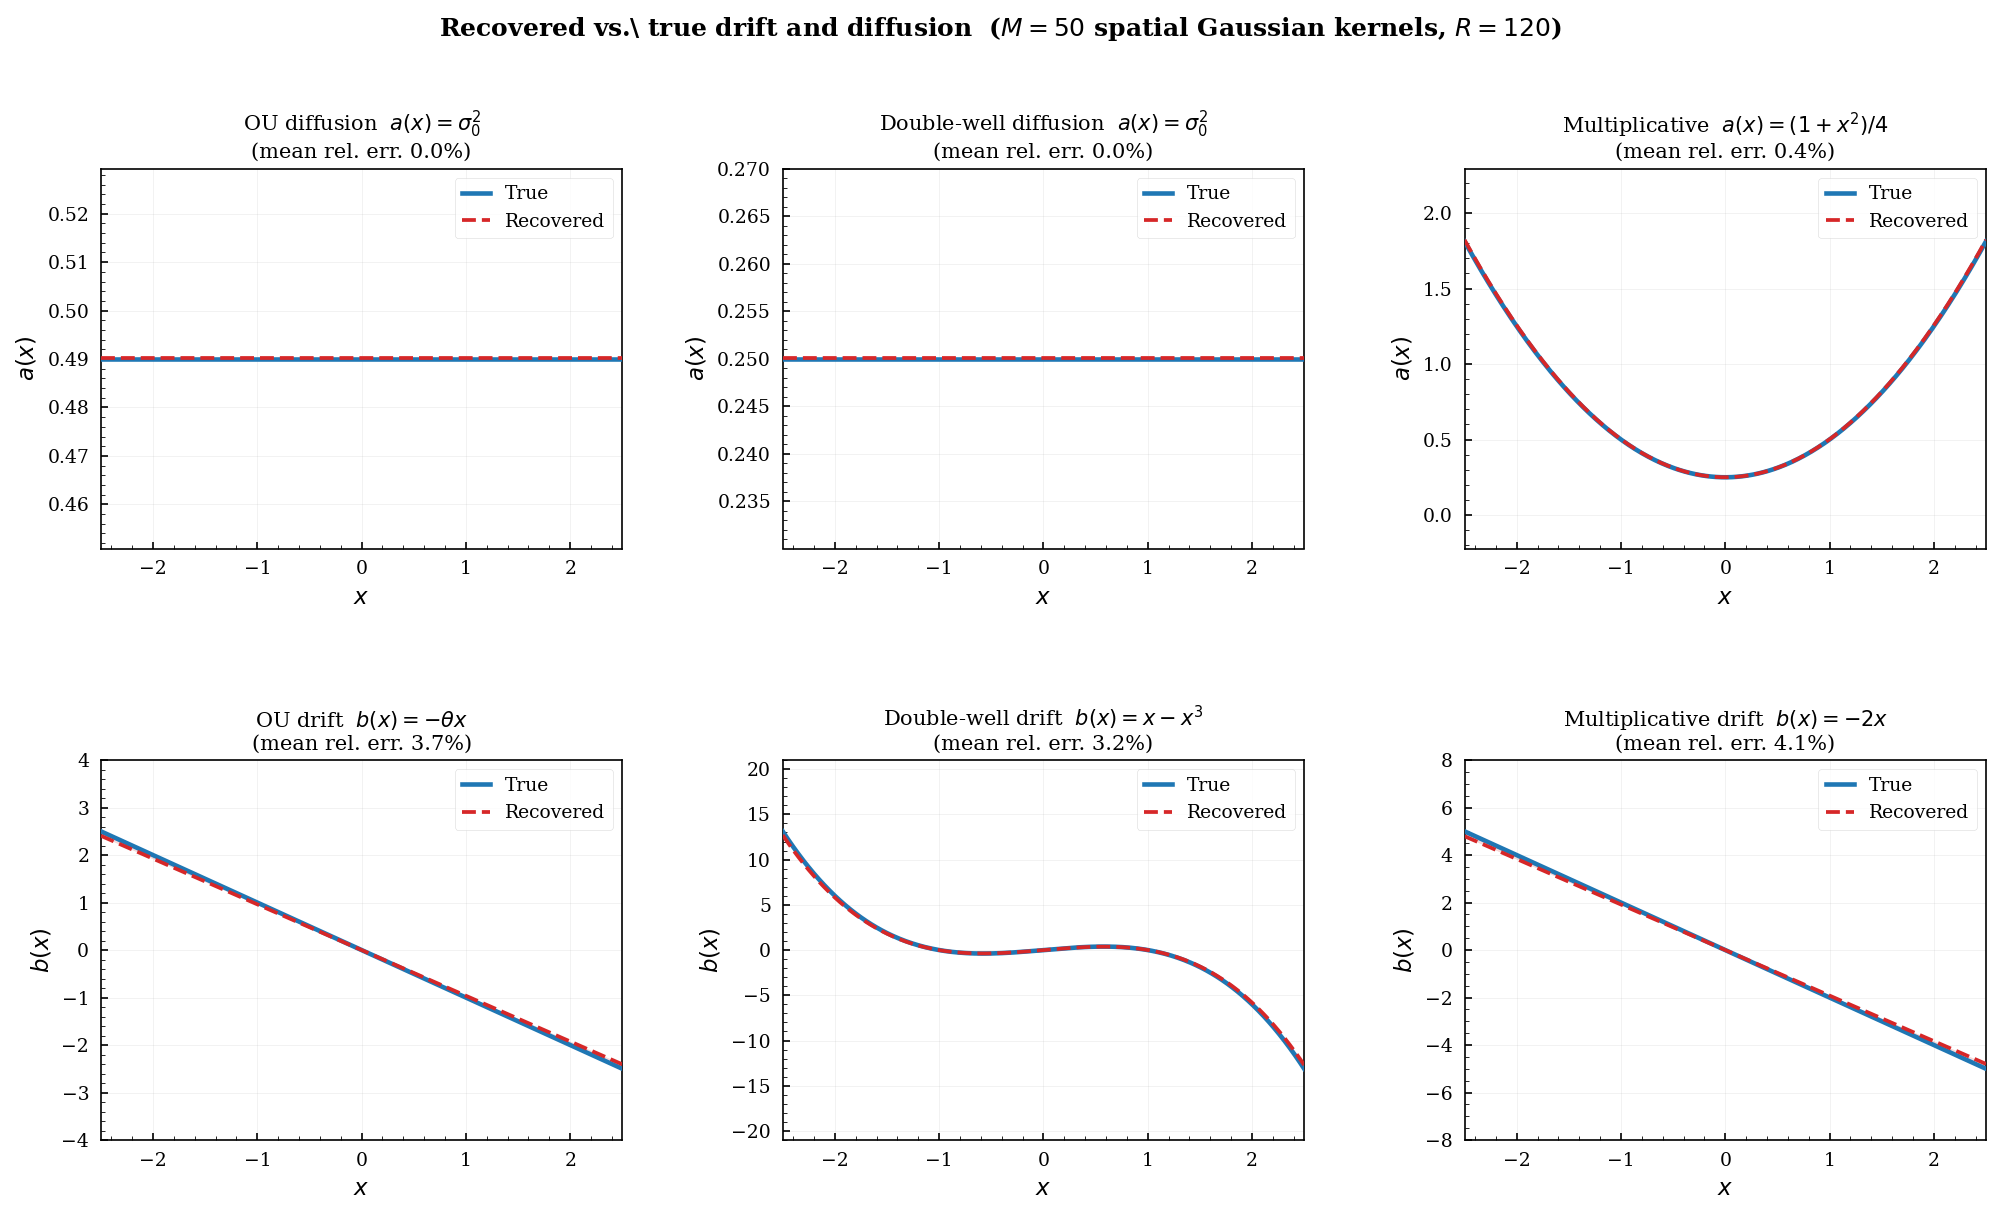

In [ ]:
# ── Cell 4: Figure 1 -- Recovered vs true functions ──────────────────────────
# Layout: diffusions top row, drifts bottom row  (user preference).
# x_plt clipped to [-2.5, 2.5] to prevent x^3 blow-up at edges.
# smart_ylim: widens axis for near-constant panels so lines look overlapping.

x_plt = np.linspace(-2.5, 2.5, 401)

def ev_plt(c): return poly(x_plt) @ c

bh_ou_p = ev_plt(cb_ou); ah_ou_p = np.full_like(x_plt, ca_ou[0])
bh_dw_p = ev_plt(cb_dw); ah_dw_p = np.full_like(x_plt, ca_dw[0])
bh_m_p  = ev_plt(cb_m);  ah_m_p  = np.clip(ev_plt(ca_m), 1e-9, None)
bt_ou_p = b_ou(x_plt);   at_ou_p = np.full_like(x_plt, SIGMA0_OU**2)
bt_dw_p = b_dw(x_plt);   at_dw_p = np.full_like(x_plt, SIGMA0_DW**2)
bt_m_p  = b_mult(x_plt); at_m_p  = 0.25*(1. + x_plt**2)

def mre(yt, yh):
    return np.mean(np.abs(yt - yh)) / (np.mean(np.abs(yt)) + 1e-12) * 100.

def smart_ylim(yt, yh):
    all_v  = np.concatenate([yt, yh])
    lo, hi = all_v.min(), all_v.max()
    span   = hi - lo
    scale  = np.abs(all_v).mean() + 1e-12
    if span < 0.08 * scale:          # near-constant: widen so lines overlap
        centre = 0.5 * (lo + hi)
        half   = max(0.08 * scale, span * 4)
        return [centre - half, centre + half]
    return [lo - 0.30*span, hi + 0.30*span]

# TOP ROW = diffusions, BOTTOM ROW = drifts  (user's layout)
panels = [
    (at_ou_p, ah_ou_p, r'OU diffusion  $a(x)=\sigma_0^2$',           r'$a(x)$'),
    (at_dw_p, ah_dw_p, r'Double-well diffusion  $a(x)=\sigma_0^2$',  r'$a(x)$'),
    (at_m_p,  ah_m_p,  r'Multiplicative  $a(x)=(1+x^2)/4$',          r'$a(x)$'),
    (bt_ou_p, bh_ou_p, r'OU drift  $b(x)=-\theta x$',                r'$b(x)$'),
    (bt_dw_p, bh_dw_p, r'Double-well drift  $b(x)=x-x^3$',           r'$b(x)$'),
    (bt_m_p,  bh_m_p,  r'Multiplicative drift  $b(x)=-2x$',           r'$b(x)$'),
]

with matplotlib.rc_context(PUB_RC):
    fig, axes = plt.subplots(2, 3, figsize=(13.5, 8))
    fig.suptitle(
        r'Recovered vs.\ true drift and diffusion  '
        r'($M=50$ spatial Gaussian kernels, $R=120$)',
        fontsize=12, fontweight='bold', y=1.01)
    for ax, (yt, yh, title, ylabel) in zip(axes.ravel(), panels):
        err = mre(yt, yh)
        ax.plot(x_plt, yt, lw=2.2, color=C_T, label='True',     zorder=3)
        ax.plot(x_plt, yh, lw=1.8, color=C_H, label='Recovered',
                ls='--', zorder=4)
        ax.fill_between(x_plt, yt, yh, alpha=0.15, color=C_H, zorder=2)
        ax.set_title(f'{title}\n(mean rel. err. {err:.1f}%)', fontsize=10, pad=5)
        ax.set_xlabel(r'$x$'); ax.set_ylabel(ylabel)
        ax.set_xlim(-2.5, 2.5); ax.set_ylim(smart_ylim(yt, yh))
        ax.legend(handlelength=1.5, framealpha=0.8)
        ax.grid(True, alpha=0.18, lw=0.4)
    plt.tight_layout(h_pad=3.8, w_pad=2.5)
    savefig(fig, 'fig1_recovered_vs_true.pdf')
    plt.show()


  saved -> ./pub_figs/fig2_lasso_paths.pdf


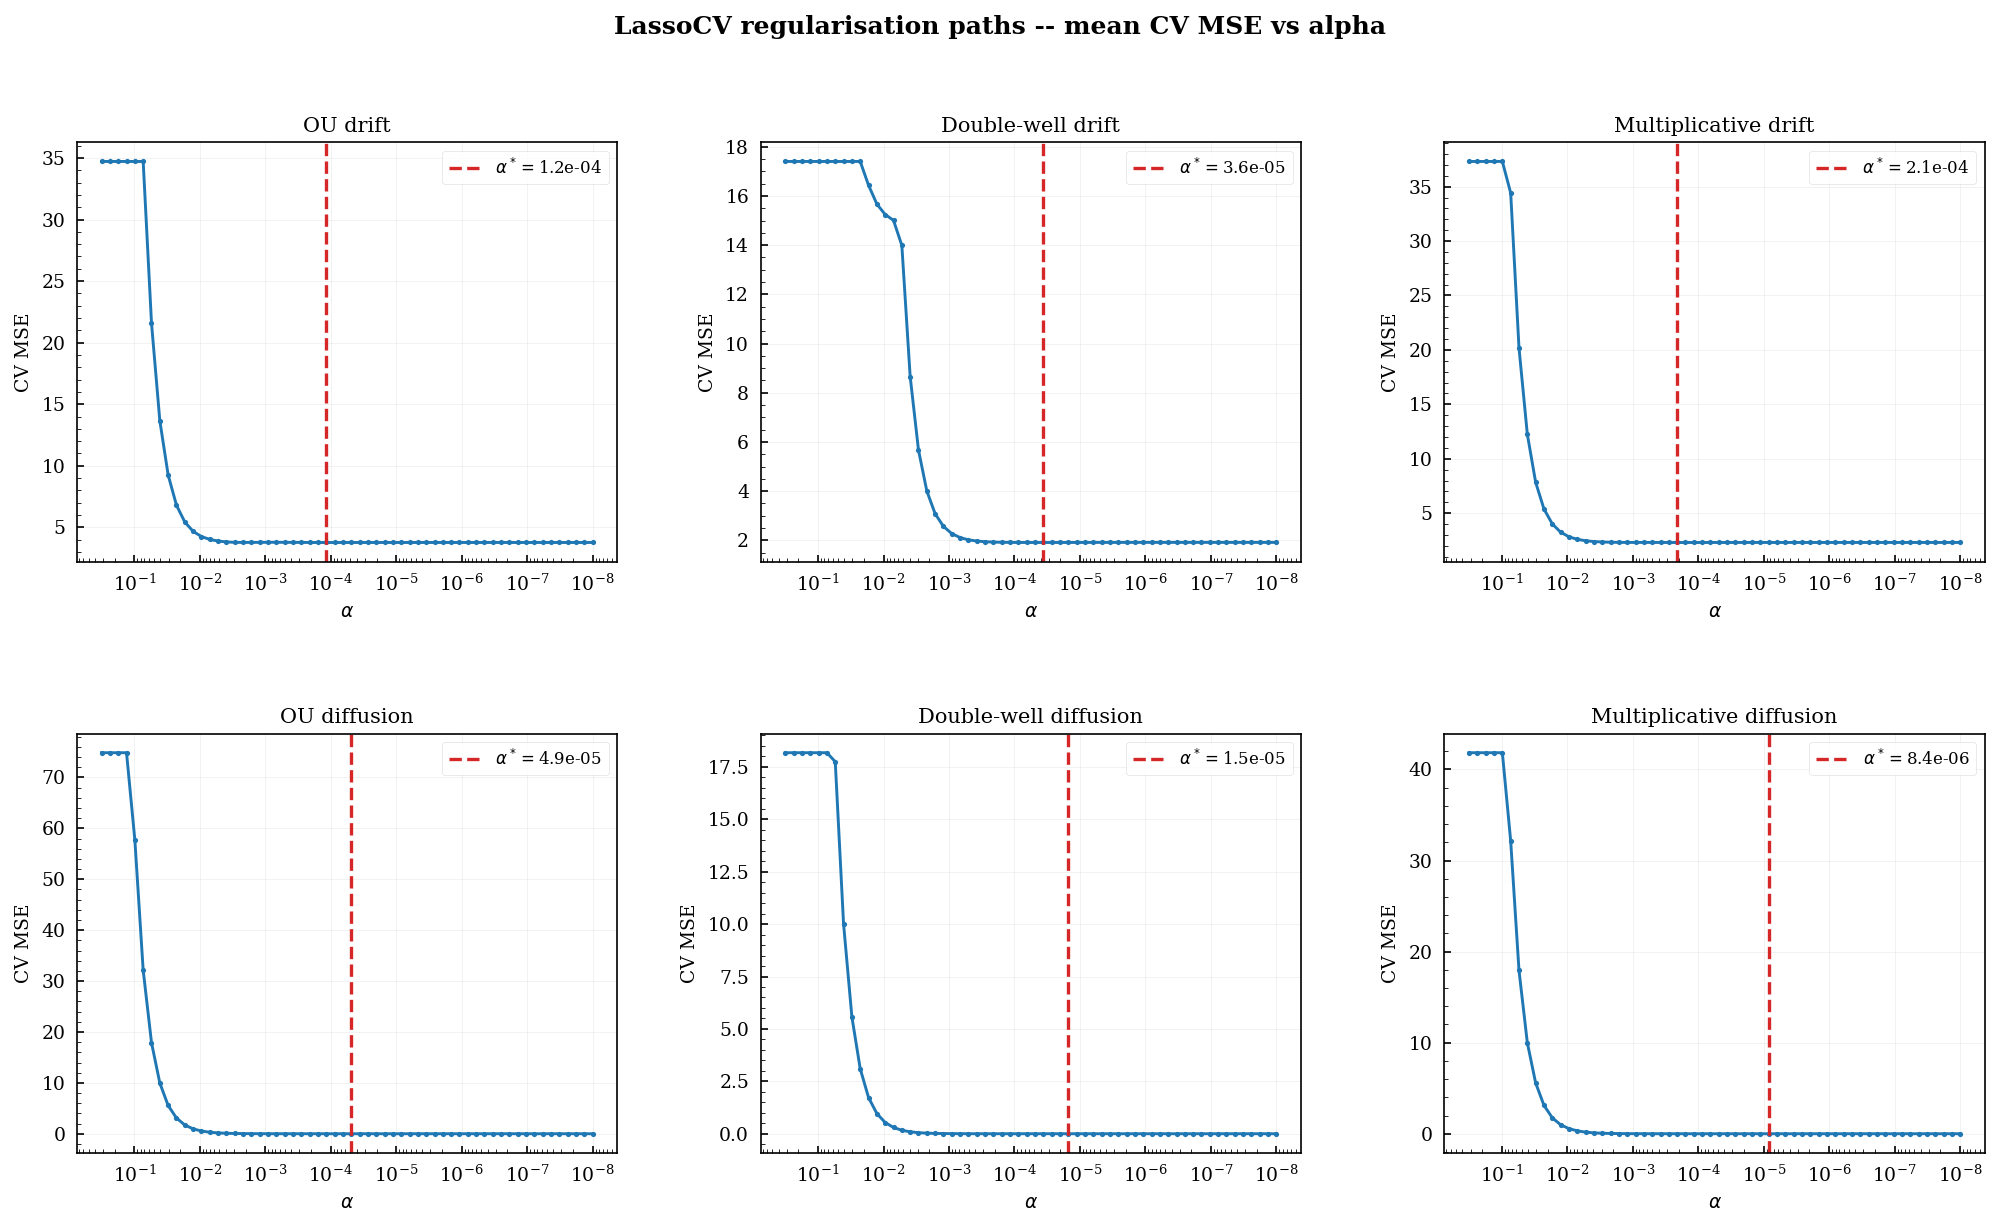

In [ ]:
# ── Cell 5: Figure 2 -- LassoCV regularisation paths ─────────────────────────

def lasso_panel(ax, lasso, title):
    mse = lasso.mse_path_.mean(axis=1)
    ax.semilogx(lasso.alphas_, mse, 'o-', ms=2.5, lw=1.4, color=C_T)
    ax.axvline(lasso.alpha_, color=C_H, ls='--', lw=1.6,
               label=r'$\alpha^*=$' + f'{lasso.alpha_:.1e}')
    ax.invert_xaxis()
    ax.set_xlabel(r'$\alpha$', fontsize=9); ax.set_ylabel('CV MSE', fontsize=9)
    ax.set_title(title, fontsize=10, pad=5)
    ax.legend(framealpha=0.8, fontsize=8)
    ax.grid(True, alpha=0.18, lw=0.4)

with matplotlib.rc_context(PUB_RC):
    fig, axes = plt.subplots(2, 3, figsize=(13.5, 8))
    fig.suptitle('LassoCV regularisation paths -- mean CV MSE vs alpha',
                 fontsize=12, fontweight='bold', y=1.02)
    tasks = [
        (axes[0,0], lb_ou, 'OU drift'),
        (axes[0,1], lb_dw, 'Double-well drift'),
        (axes[0,2], lb_m,  'Multiplicative drift'),
        (axes[1,0], la_ou, 'OU diffusion'),
        (axes[1,1], la_dw, 'Double-well diffusion'),
        (axes[1,2], la_m,  'Multiplicative diffusion'),
    ]
    for ax, lasso, title in tasks:
        lasso_panel(ax, lasso, title)
    plt.tight_layout(h_pad=3.5, w_pad=2.5)
    savefig(fig, 'fig2_lasso_paths.pdf')
    plt.show()

/tmp/ipykernel_1144/4081812751.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  pi   = np.exp(lp); pi /= np.trapz(pi, xs)
/tmp/ipykernel_1144/4081812751.py:11: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  def tv(p, q, x): return 0.5 * np.trapz(np.abs(p - q), x)


TV  OU=0.0093  DW=0.0071  Mult=0.0099
  saved -> ./pub_figs/fig3_stationary_density.pdf


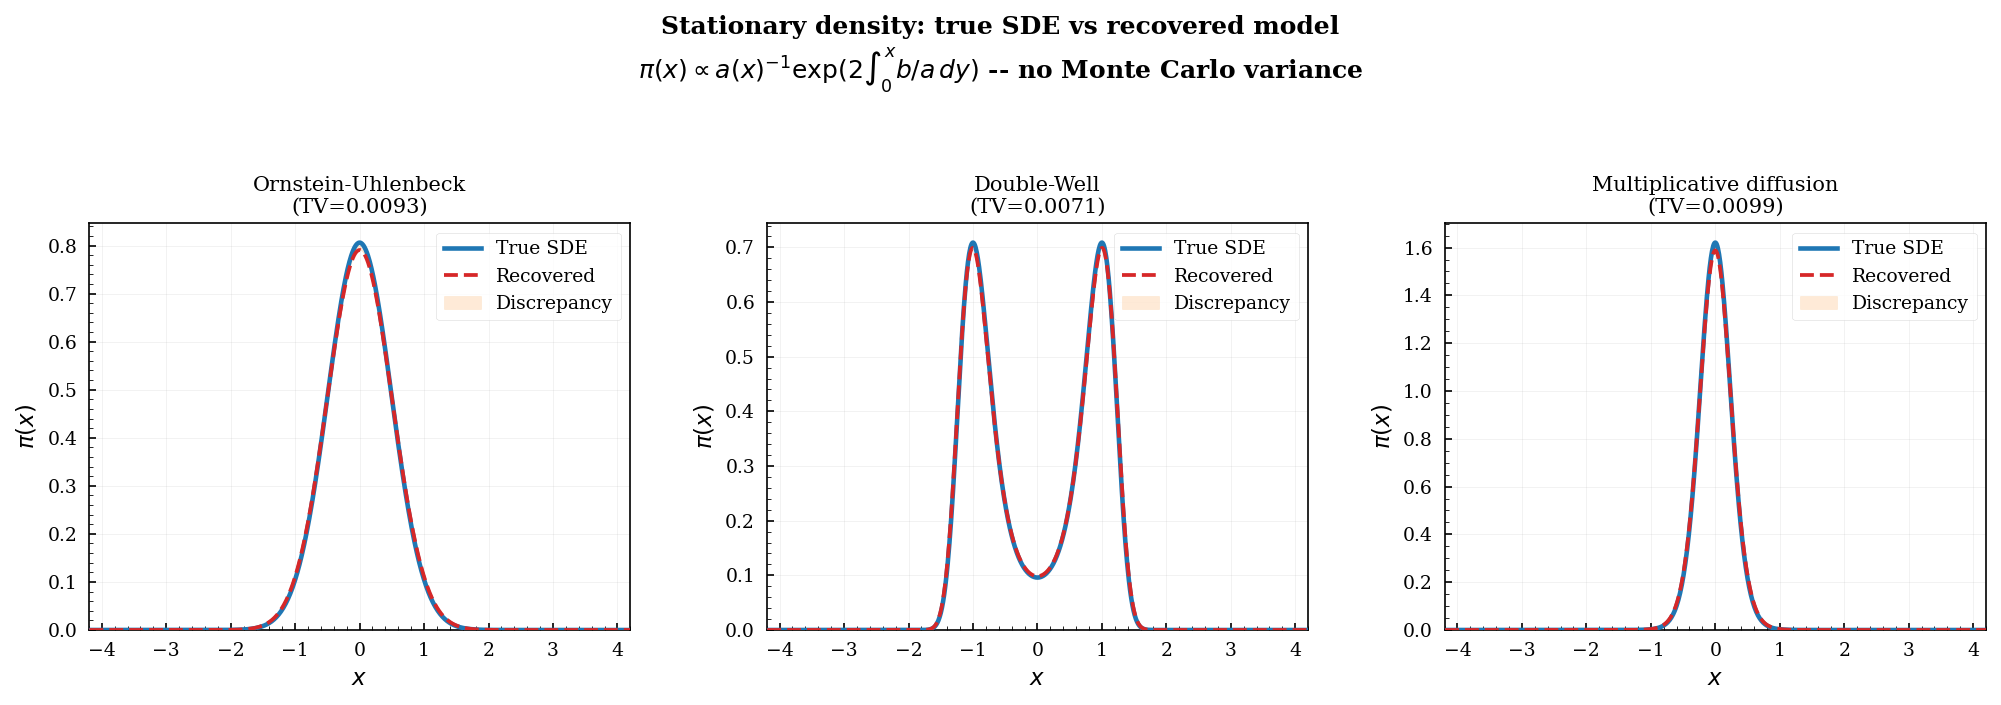

In [ ]:
import numpy as np
# ── Cell 6: Figure 3 -- Stationary density (Fokker-Planck) ───────────────────

def fp_density(b_fn, a_fn, xs):
    bv = b_fn(xs); av = a_fn(xs)
    intg = cumulative_trapezoid(bv / (av + 1e-14), xs, initial=0.)
    lp   = 2.*intg - np.log(av + 1e-14); lp -= lp.max()
    pi   = np.exp(lp); pi /= np.trapz(pi, xs)
    return pi

def tv(p, q, x): return 0.5 * np.trapz(np.abs(p - q), x)

xs = np.linspace(-4.5, 4.5, 1000)
pi_ou_t = fp_density(b_ou,   lambda x: np.full_like(x, SIGMA0_OU**2), xs)
pi_dw_t = fp_density(b_dw,   lambda x: np.full_like(x, SIGMA0_DW**2), xs)
pi_m_t  = fp_density(b_mult, lambda x: 0.25*(1.+x**2), xs)
pi_ou_h = fp_density(
    lambda x: poly(np.atleast_1d(x)) @ cb_ou,
    lambda x: np.full_like(np.atleast_1d(x), float(ca_ou[0])), xs)
pi_dw_h = fp_density(
    lambda x: poly(np.atleast_1d(x)) @ cb_dw,
    lambda x: np.full_like(np.atleast_1d(x), float(ca_dw[0])), xs)
pi_m_h  = fp_density(
    lambda x: poly(np.atleast_1d(x)) @ cb_m,
    lambda x: np.clip(poly(np.atleast_1d(x)) @ ca_m, 1e-9, None), xs)

tv_ou = tv(pi_ou_t, pi_ou_h, xs)
tv_dw = tv(pi_dw_t, pi_dw_h, xs)
tv_m  = tv(pi_m_t,  pi_m_h,  xs)
print(f'TV  OU={tv_ou:.4f}  DW={tv_dw:.4f}  Mult={tv_m:.4f}')

with matplotlib.rc_context(PUB_RC):
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.5))
    fig.suptitle(
        r'Stationary density: true SDE vs recovered model' '\n'
        r'$\pi(x)\propto a(x)^{-1}\exp(2\int_0^x b/a\,dy)$ -- no Monte Carlo variance',
        fontsize=12, fontweight='bold', y=1.04)
    data3 = [
        (pi_ou_t, pi_ou_h, f'Ornstein-Uhlenbeck\n(TV={tv_ou:.4f})'),
        (pi_dw_t, pi_dw_h, f'Double-Well\n(TV={tv_dw:.4f})'),
        (pi_m_t,  pi_m_h,  f'Multiplicative diffusion\n(TV={tv_m:.4f})'),
    ]
    for ax, (pt, ph, title) in zip(axes, data3):
        ax.plot(xs, pt, lw=2.2, color=C_T, label='True SDE',  zorder=4)
        ax.plot(xs, ph, lw=1.8, color=C_H, label='Recovered', ls='--', zorder=5)
        ax.fill_between(xs, pt, ph, alpha=0.25, color='#fdae61', label='Discrepancy')
        ax.set_xlim(-4.2, 4.2); ax.set_ylim(bottom=0.)
        ax.set_xlabel(r'$x$'); ax.set_ylabel(r'$\pi(x)$')
        ax.set_title(title, fontsize=10, pad=5)
        ax.legend(framealpha=0.8); ax.grid(True, alpha=0.18, lw=0.4)
    plt.tight_layout(w_pad=2.5)
    savefig(fig, 'fig3_stationary_density.pdf')
    plt.show()

Simulating long trajectories for ACF ...


/tmp/ipykernel_1144/1942513386.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X[i+1] = xn + float(b_fn(xn))*dt + float(s_fn(xn))*sqdt*xi[i]
/tmp/ipykernel_1144/1942513386.py:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X[i+1] = xn + float(b_fn(xn))*dt + float(s_fn(xn))*sqdt*xi[i]
/tmp/ipykernel_1144/1942513386.py:41: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lambda x: np.sqrt(max(float(poly([[x]]) @ ca_m), 1e-9)),


OU spectral gap -- true 1.000  recovered 0.963  (err 3.7%)
  saved -> ./pub_figs/fig4_autocorr.pdf


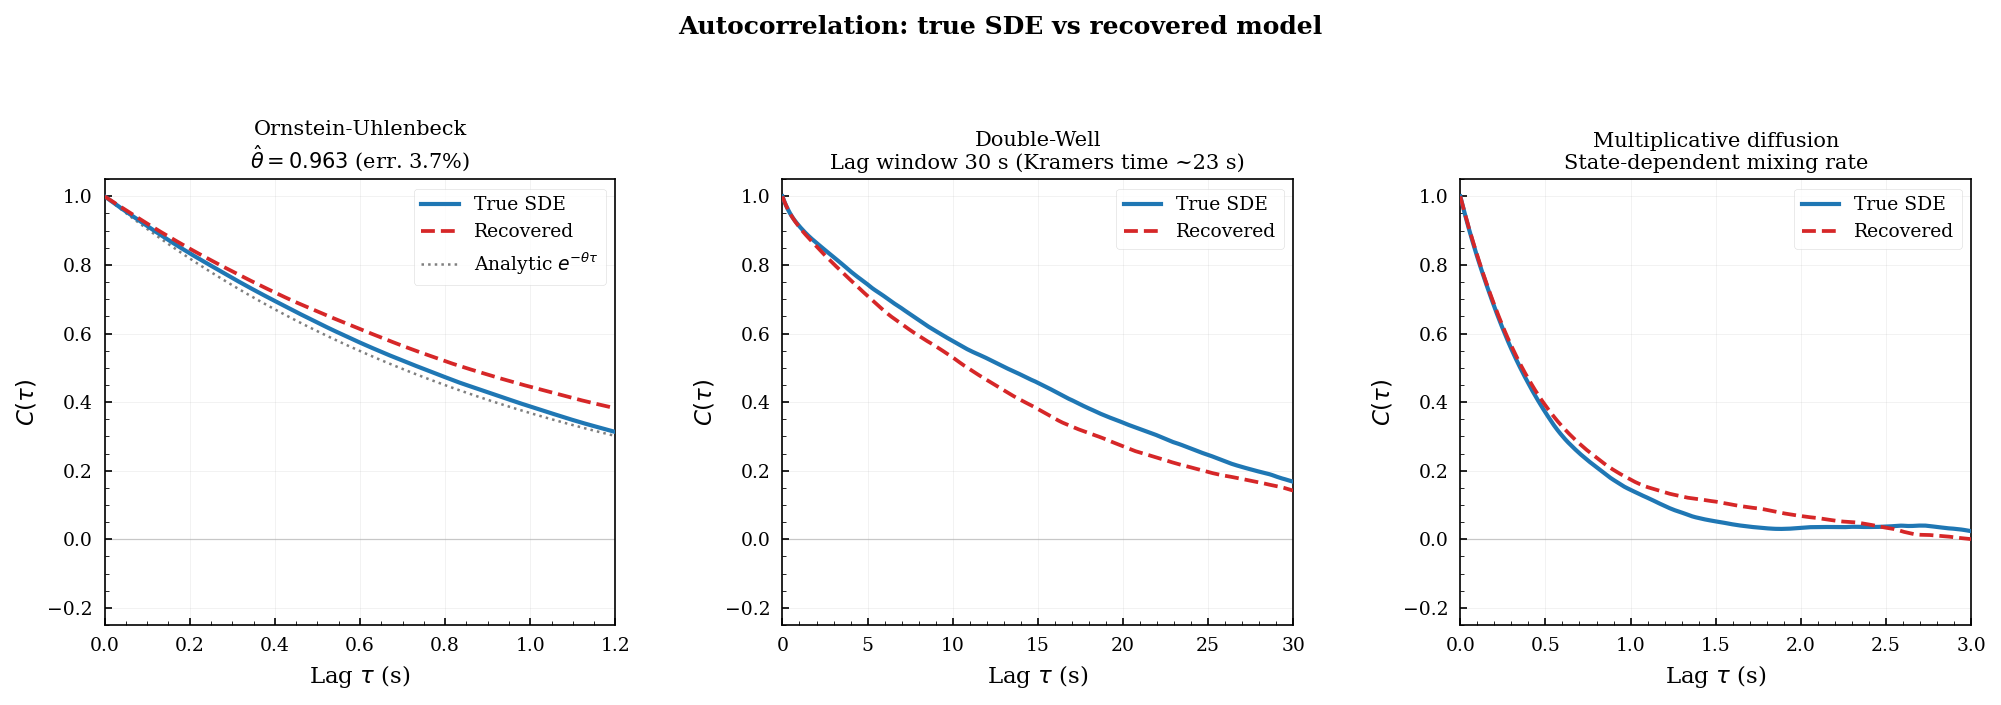

In [ ]:
# ── Cell 7: Figure 4 -- Autocorrelation ──────────────────────────────────────
# Fix: use FFT-based ACF and per-panel lag lengths.
# Double-well Kramers time ~23s, so use lag window of 30s to show full decay.

def acf_fft(x, max_lag):
    x   = x - x.mean()
    n   = len(x)
    f   = np.fft.rfft(x, n=2*n)
    ac  = np.fft.irfft(f * np.conj(f))[:max_lag + 1]
    ac /= ac[0]
    return ac.real

def sim_long(b_fn, s_fn, n=200_000, burn=5_000, dt=DT, clip=12.):
    X = np.empty(n+1); X[0] = 0.; sqdt = np.sqrt(dt)
    xi = np.random.randn(n)
    for i in range(n):
        xn = float(np.clip(X[i], -clip, clip))
        X[i+1] = xn + float(b_fn(xn))*dt + float(s_fn(xn))*sqdt*xi[i]
    return X[burn:]

np.random.seed(99)
print('Simulating long trajectories for ACF ...')

# OU: 300k steps, lag 1.2s (600 steps) -- relaxation time ~1s
N_OU  = 300_000; LAG_OU  = 600
xt_ou = sim_long(b_ou, s_ou, n=N_OU)
xr_ou = sim_long(lambda x: poly([[x]]) @ cb_ou,
                 lambda x: np.sqrt(max(float(ca_ou[0]), 1e-9)), n=N_OU)

# Double-well: 2M steps, lag 30s (15000 steps) -- Kramers time ~23s
N_DW  = 2_000_000; LAG_DW = 15_000; BURN_DW = 50_000
xt_dw = sim_long(b_dw, s_dw, n=N_DW, burn=BURN_DW)
xr_dw = sim_long(lambda x: poly([[x]]) @ cb_dw,
                 lambda x: np.sqrt(max(float(ca_dw[0]), 1e-9)),
                 n=N_DW, burn=BURN_DW)

# Multiplicative: 500k steps, lag 3s (1500 steps)
N_MT  = 500_000; LAG_MT  = 1_500
xt_m  = sim_long(b_mult, s_mult, n=N_MT, burn=10_000)
xr_m  = sim_long(lambda x: poly([[x]]) @ cb_m,
                 lambda x: np.sqrt(max(float(poly([[x]]) @ ca_m), 1e-9)),
                 n=N_MT, burn=10_000)

th_rec = float(-cb_ou[1])
print(f'OU spectral gap -- true {THETA_OU:.3f}  recovered {th_rec:.3f}  '
      f'(err {abs(th_rec-THETA_OU)/THETA_OU*100:.1f}%)')

with matplotlib.rc_context(PUB_RC):
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.5))
    fig.suptitle('Autocorrelation: true SDE vs recovered model',
                 fontsize=12, fontweight='bold', y=1.04)

    panels_ac = [
        (xt_ou, xr_ou, LAG_OU, 'Ornstein-Uhlenbeck',
         r'$\hat\theta={:.3f}$ (err. {:.1f}%)'.format(
             th_rec, abs(th_rec-THETA_OU)/THETA_OU*100),
         np.exp(-THETA_OU * np.arange(LAG_OU+1)*DT)),
        (xt_dw, xr_dw, LAG_DW, 'Double-Well',
         'Lag window 30 s (Kramers time ~23 s)', None),
        (xt_m,  xr_m,  LAG_MT, 'Multiplicative diffusion',
         'State-dependent mixing rate', None),
    ]
    for ax, (xt, xr, ml, title, note, ref) in zip(axes, panels_ac):
        lags_s = np.arange(ml+1) * DT
        ax.plot(lags_s, acf_fft(xt, ml), lw=2.,  color=C_T, label='True SDE',   zorder=4)
        ax.plot(lags_s, acf_fft(xr, ml), lw=1.8, color=C_H, label='Recovered',
                ls='--', zorder=5)
        if ref is not None:
            ax.plot(lags_s, ref, lw=1.2, color=C_RF, ls=':',
                    label=r'Analytic $e^{-\theta\tau}$', zorder=3)
        ax.axhline(0., color='#ccc', lw=0.6, zorder=1)
        ax.set_xlabel(r'Lag $\tau$ (s)'); ax.set_ylabel(r'$C(\tau)$')
        ax.set_title(f'{title}\n{note}', fontsize=10, pad=5)
        ax.set_ylim(-0.25, 1.05); ax.set_xlim(0, lags_s[-1])
        ax.legend(framealpha=0.8); ax.grid(True, alpha=0.18, lw=0.4)
    plt.tight_layout(w_pad=2.5)
    savefig(fig, 'fig4_autocorr.pdf')
    plt.show()

  saved -> ./pub_figs/fig5a_theoretical_noise_scaling.pdf


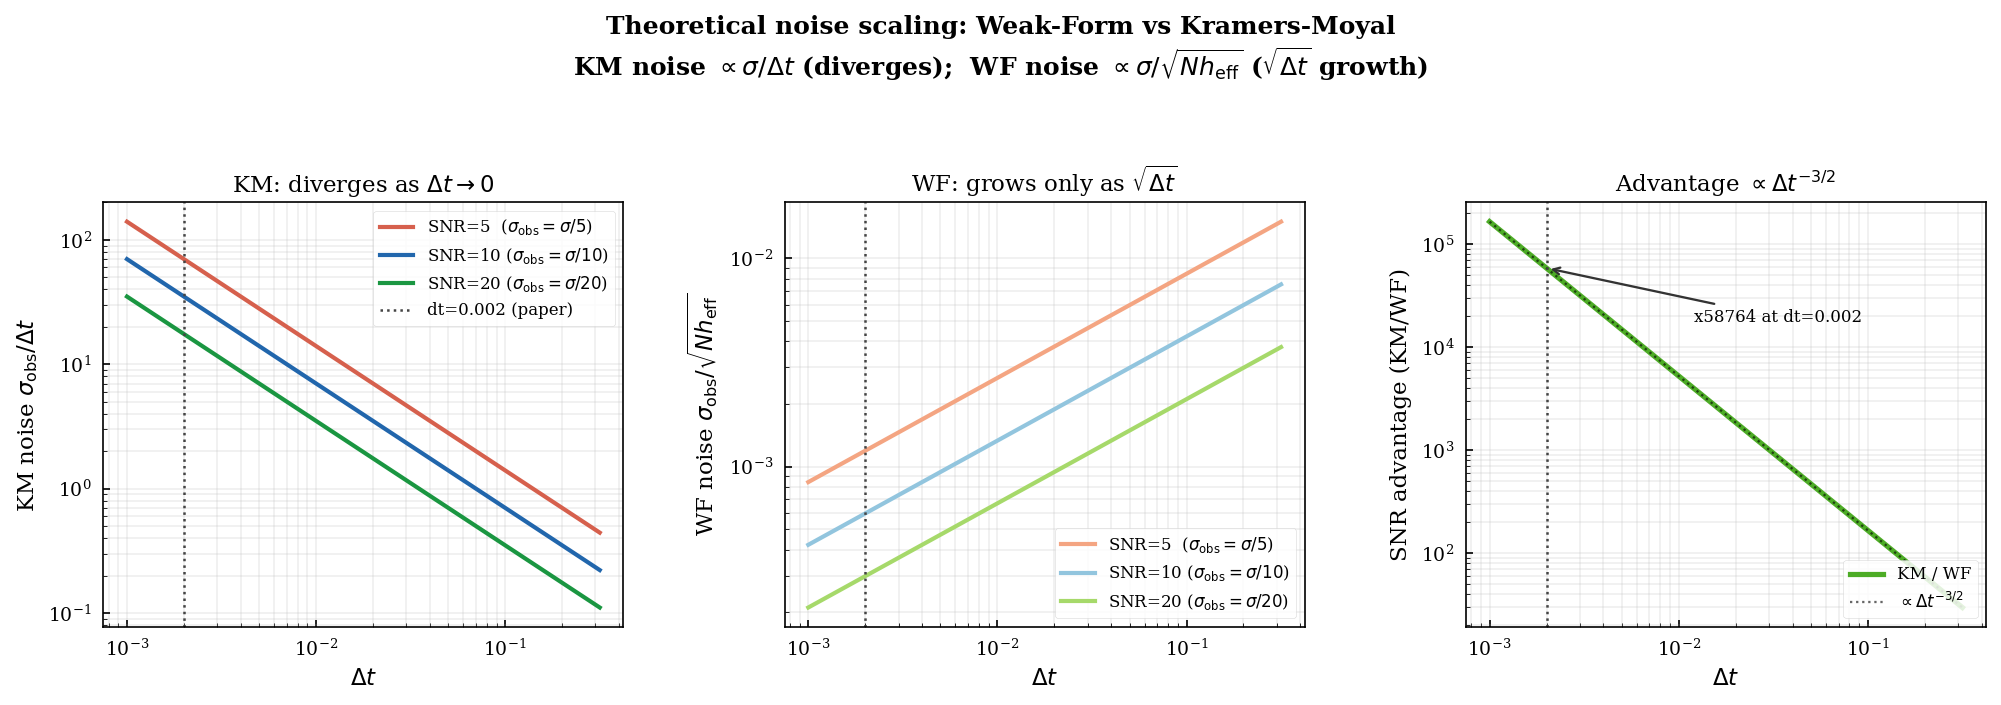

WF advantage at dt=0.002: x58764   h_eff=0.2757


In [ ]:
# ── Cell 8: Figure 5 -- Theoretical noise scaling ─────────────────────────────

dt_v  = np.logspace(-3, -0.5, 400)
N_v   = (T / dt_v).astype(int)
h_eff = np.sqrt(np.pi / 2) * H_OU_DW
snrs = [
    (r'SNR=5  ($\sigma_\mathrm{obs}=\sigma/5$)',
     SIGMA0_OU/5,  '#d6604d', '#f4a582'),
    (r'SNR=10 ($\sigma_\mathrm{obs}=\sigma/10$)',
     SIGMA0_OU/10, '#2166ac', '#92c5de'),
    (r'SNR=20 ($\sigma_\mathrm{obs}=\sigma/20$)',
     SIGMA0_OU/20, '#1a9641', '#a6d96a'),
]

with matplotlib.rc_context(PUB_RC):
    fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.5))
    fig.suptitle(
        r'Theoretical noise scaling: Weak-Form vs Kramers-Moyal' '\n'
        r'KM noise $\propto\sigma/\Delta t$ (diverges);  '
        r'WF noise $\propto\sigma/\sqrt{Nh_\mathrm{eff}}$ ($\sqrt{\Delta t}$ growth)',
        fontsize=12, fontweight='bold', y=1.04)
    ax = axes[0]
    for lbl, sig, col, _ in snrs:
        ax.loglog(dt_v, sig/dt_v, color=col, lw=2., label=lbl)
    ax.axvline(DT, color='#444', ls=':', lw=1.2, label=f'dt={DT} (paper)')
    ax.set_xlabel(r'$\Delta t$')
    ax.set_ylabel(r'KM noise $\sigma_\mathrm{obs}/\Delta t$')
    ax.set_title(r'KM: diverges as $\Delta t\to 0$', pad=5)
    ax.legend(framealpha=0.85, fontsize=8); ax.grid(True,alpha=0.2,which='both')

    ax = axes[1]
    for lbl, sig, _, col in snrs:
        ax.loglog(dt_v, sig/np.sqrt(N_v*h_eff), color=col, lw=2., label=lbl)
    ax.axvline(DT, color='#444', ls=':', lw=1.2)
    ax.set_xlabel(r'$\Delta t$')
    ax.set_ylabel(r'WF noise $\sigma_\mathrm{obs}/\sqrt{Nh_\mathrm{eff}}$')
    ax.set_title(r'WF: grows only as $\sqrt{\Delta t}$', pad=5)
    ax.legend(framealpha=0.85, fontsize=8); ax.grid(True,alpha=0.2,which='both')

    ax = axes[2]
    ratio = np.sqrt(N_v*h_eff) / dt_v
    ax.loglog(dt_v, ratio, color='#4dac26', lw=2.5, label='KM / WF')
    i0  = len(dt_v)//2
    ax.loglog(dt_v, ratio[i0]*(dt_v/dt_v[i0])**(-1.5), 'k:', lw=1.1, alpha=0.6,
              label=r'$\propto\Delta t^{-3/2}$')
    ax.axvline(DT, color='#444', ls=':', lw=1.2)
    idx = np.argmin(np.abs(dt_v - DT)); adv = ratio[idx]
    ax.annotate(f'x{adv:.0f} at dt={DT}',
                xy=(DT, adv), xytext=(DT*6, adv*0.3),
                arrowprops=dict(arrowstyle='->', color='#333', lw=1.1), fontsize=8)
    ax.set_xlabel(r'$\Delta t$'); ax.set_ylabel('SNR advantage (KM/WF)')
    ax.set_title(r'Advantage $\propto\Delta t^{-3/2}$', pad=5)
    ax.legend(framealpha=0.85, fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.2, which='both')
    plt.tight_layout(w_pad=2.5)
    savefig(fig, 'fig5a_theoretical_noise_scaling.pdf')
    plt.show()
print(f'WF advantage at dt={DT}: x{adv:.0f}   h_eff={h_eff:.4f}')

Fig 6: dt=0.005, M=40, R=8, 25 reps ...
Done in 91.9s


/tmp/ipykernel_1144/3751063388.py:58: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot([e_sp[T_bx], e_tm[T_bx]],


  saved -> ./pub_figs/fig6_endogeneity_bias.pdf


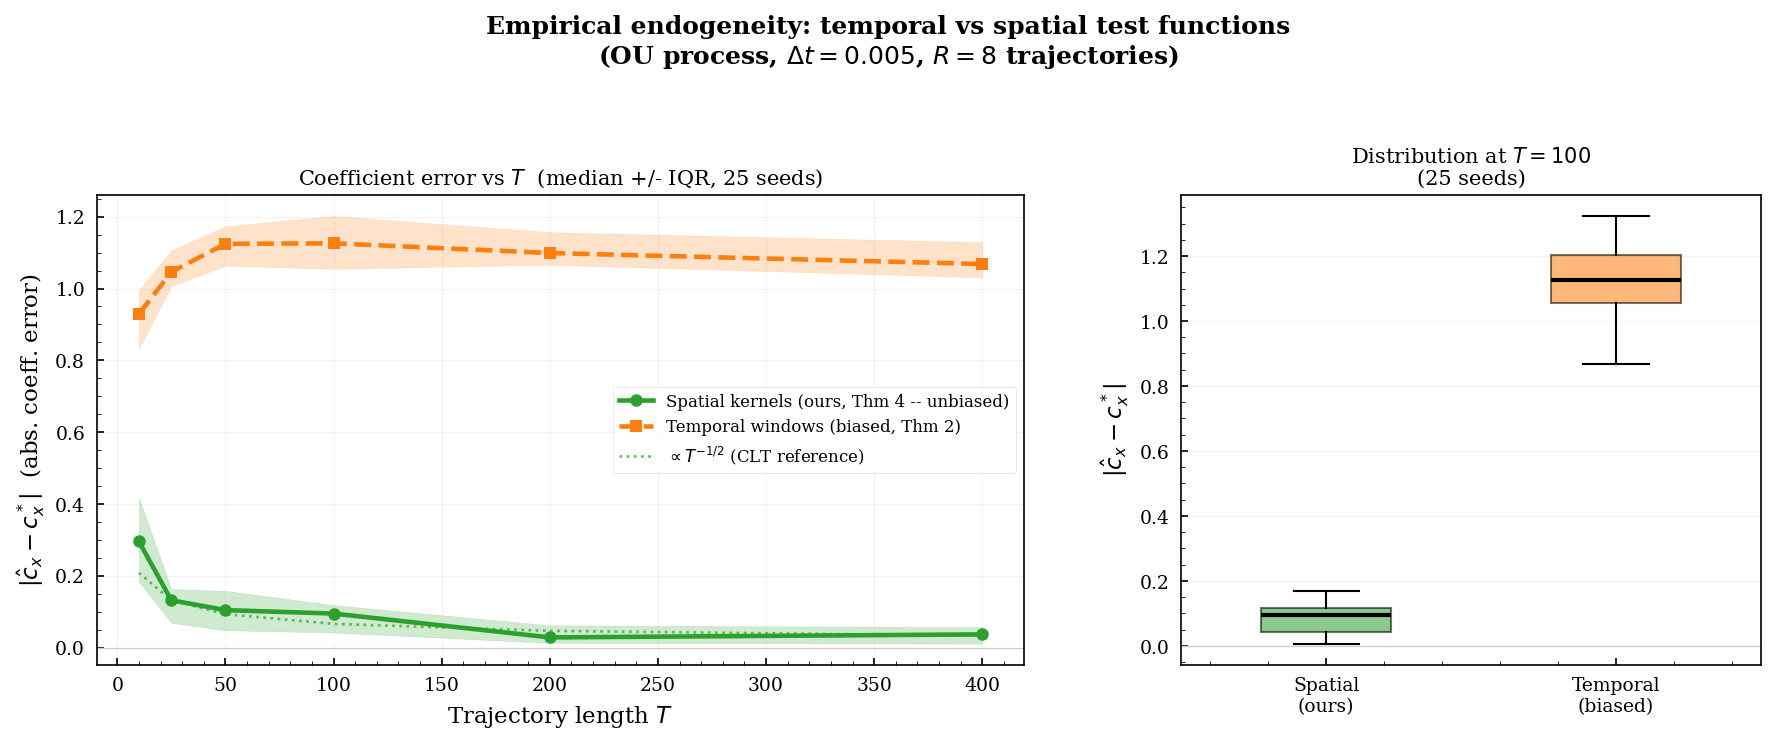

In [ ]:
# ── Cell 9: Figure 6 -- Empirical endogeneity bias vs T ──────────────────────

DT_E = 0.005; R_E = 8; NREPS_E = 25; M_E = 40; H_E = 0.25
T_VALS = np.array([10, 25, 50, 100, 200, 400])

print(f'Fig 6: dt={DT_E}, M={M_E}, R={R_E}, {NREPS_E} reps ...')
t6 = time.time()
e_sp = {T: [] for T in T_VALS}
e_tm = {T: [] for T in T_VALS}

for rep in range(NREPS_E):
    for Tv in T_VALS:
        nv = int(Tv / DT_E)
        np.random.seed(rep*1000 + int(Tv))
        Xb = sim_batch(b_ou, s_ou, R_E, n_steps=nv, dt=DT_E)
        cv = np.linspace(-2.5, 2.5, M_E)
        A, B, _, _ = weak_mats(Xb, cv, H_E, dt=DT_E)
        e_sp[Tv].append(abs(ols(A, B)[1] - C_B_OU[1]))
        e_tm[Tv].append(abs(temporal_ols(Xb, M_E, dt=DT_E)[1] - C_B_OU[1]))

print(f'Done in {time.time()-t6:.1f}s')

def iqr_summary(d, T_vals):
    return (np.array([np.median(d[T]) for T in T_vals]),
            np.array([np.percentile(d[T], 25) for T in T_vals]),
            np.array([np.percentile(d[T], 75) for T in T_vals]))

ms_sp, ls_sp, hs_sp = iqr_summary(e_sp, T_VALS)
ms_tm, ls_tm, hs_tm = iqr_summary(e_tm, T_VALS)

with matplotlib.rc_context(PUB_RC):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8),
                             gridspec_kw={'width_ratios': [1.6, 1]})
    fig.suptitle(
        r'Empirical endogeneity: temporal vs spatial test functions' '\n'
        r'(OU process, $\Delta t=' + f'{DT_E}' + r'$, $R=' + f'{R_E}' + r'$ trajectories)',
        fontsize=12, fontweight='bold', y=1.03)

    ax = axes[0]
    ax.plot(T_VALS, ms_sp, 'o-', color=C_SP, lw=2.2, ms=6,
            label='Spatial kernels (ours, Thm 4 -- unbiased)', zorder=4)
    ax.fill_between(T_VALS, ls_sp, hs_sp, alpha=0.22, color=C_SP)
    ax.plot(T_VALS, ms_tm, 's--', color=C_TM, lw=2.2, ms=6,
            label='Temporal windows (biased, Thm 2)', zorder=4)
    ax.fill_between(T_VALS, ls_tm, hs_tm, alpha=0.22, color=C_TM)
    c_ref = ms_sp[1] * np.sqrt(T_VALS[1])
    ax.plot(T_VALS, c_ref/np.sqrt(T_VALS), ':', color=C_SP, lw=1.3, alpha=0.7,
            label=r'$\propto T^{-1/2}$ (CLT reference)')
    ax.axhline(0., color='#ccc', lw=0.6)
    ax.set_xlabel(r'Trajectory length $T$')
    ax.set_ylabel(r'$|\hat c_x - c^*_x|$  (abs. coeff. error)')
    ax.set_title(r'Coefficient error vs $T$  (median +/- IQR, '
                 + str(NREPS_E) + ' seeds)', fontsize=10, pad=5)
    ax.legend(framealpha=0.85, fontsize=8); ax.grid(True, alpha=0.18, lw=0.4)

    T_bx = 100
    ax2 = axes[1]
    bp = ax2.boxplot([e_sp[T_bx], e_tm[T_bx]],
                     labels=['Spatial\n(ours)', 'Temporal\n(biased)'],
                     patch_artist=True, medianprops=dict(color='k', lw=2.), widths=0.45)
    for patch, col in zip(bp['boxes'], [C_SP, C_TM]):
        patch.set_facecolor(col); patch.set_alpha(0.55)
    ax2.axhline(0., color='#ccc', lw=0.6)
    ax2.set_ylabel(r'$|\hat c_x - c^*_x|$')
    ax2.set_title(r'Distribution at $T=' + str(T_bx) + r'$' '\n('
                  + str(NREPS_E) + ' seeds)', fontsize=10, pad=5)
    ax2.grid(True, alpha=0.18, lw=0.4, axis='y')
    plt.tight_layout(w_pad=3.)
    savefig(fig, 'fig6_endogeneity_bias.pdf')
    plt.show()

Fig 7: 20 seeds x R in [2, 4, 8, 15, 30, 60, 120] ...
Done in 393.4s
  saved -> ./pub_figs/fig7_convergence_rates.pdf


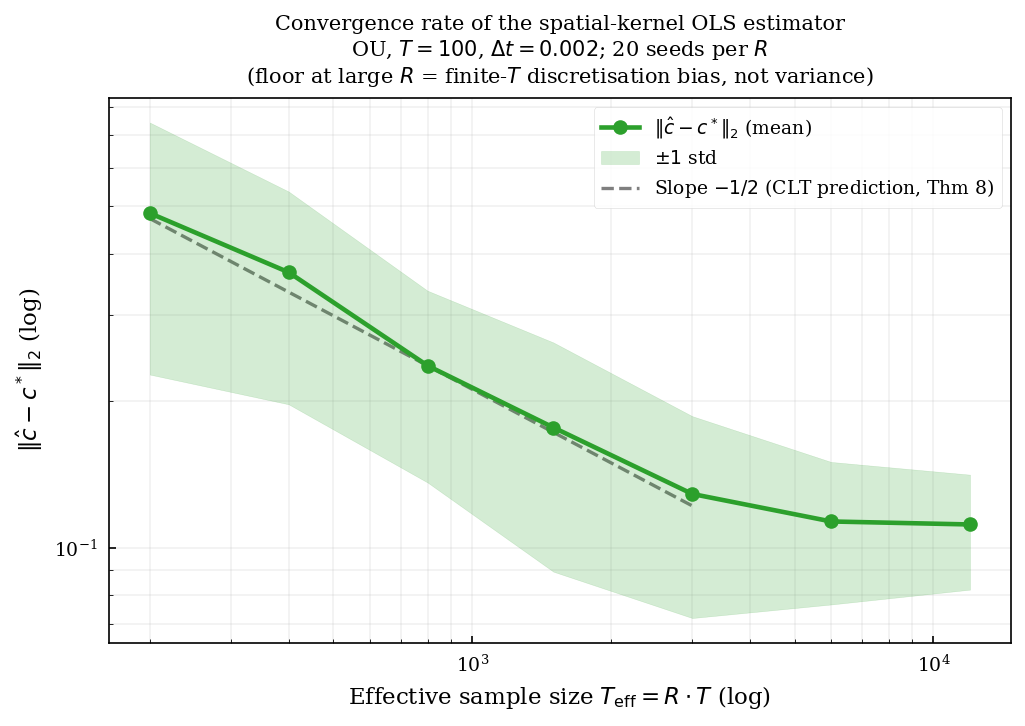

In [ ]:
# ── Cell 10: Figure 7 -- CLT convergence rate ─────────────────────────────────
# Note: OLS error floors at ~0.12 for large R because T=100 leaves finite-sample
# bias from the O(dt) Euler-Maruyama discretisation error. The -1/2 slope holds
# for the stochastic variance component (small R); the floor is deterministic.

R_VALS   = np.array([2, 4, 8, 15, 30, 60, 120])
T_EFF    = R_VALS * T
NREPS_CV = 20

print(f'Fig 7: {NREPS_CV} seeds x R in {R_VALS.tolist()} ...')
t7 = time.time()
errors_cv = {r: [] for r in R_VALS}
for seed_b in range(NREPS_CV):
    np.random.seed(seed_b * 7777)
    Xfull = sim_batch(b_ou, s_ou, int(R_VALS.max()), n_steps=N, dt=DT)
    for r in R_VALS:
        A_r, B_r, _, _ = weak_mats(Xfull[:r], c_ou, H_OU_DW, DT)
        errors_cv[r].append(norm(ols(A_r, B_r) - C_B_OU))
print(f'Done in {time.time()-t7:.1f}s')

means_cv = np.array([np.mean(errors_cv[r]) for r in R_VALS])
stds_cv  = np.array([np.std(errors_cv[r])  for r in R_VALS])

with matplotlib.rc_context(PUB_RC):
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.loglog(T_EFF, means_cv, 'o-', color=C_SP, lw=2.2, ms=7,
              label=r'$\|\hat c - c^*\|_2$ (mean)', zorder=4)
    ax.fill_between(T_EFF, np.maximum(means_cv - stds_cv, 1e-5),
                    means_cv + stds_cv, alpha=0.2, color=C_SP,
                    label=r'$\pm 1$ std', zorder=3)
    i_ref = 2
    ref_c = means_cv[i_ref] * np.sqrt(T_EFF[i_ref])
    # Only draw slope reference up to where floor becomes dominant
    T_slope = T_EFF[T_EFF <= T_EFF[4]]
    ax.loglog(T_slope, ref_c/np.sqrt(T_slope), '--', color=C_RF, lw=1.6,
              label=r'Slope $-1/2$ (CLT prediction, Thm 8)')
    ax.set_xlabel(r'Effective sample size $T_\mathrm{eff} = R\cdot T$ (log)')
    ax.set_ylabel(r'$\|\hat c - c^*\|_2$ (log)')
    ax.set_title(
        r'Convergence rate of the spatial-kernel OLS estimator' '\n'
        r'OU, $T=100$, $\Delta t=0.002$; ' + str(NREPS_CV) + r' seeds per $R$'
        '\n(floor at large $R$ = finite-$T$ discretisation bias, not variance)',
        fontsize=10, pad=7)
    ax.legend(framealpha=0.85); ax.grid(True, alpha=0.18, which='both')
    plt.tight_layout()
    savefig(fig, 'fig7_convergence_rates.pdf')
    plt.show()

Fig 8: DW hyperparameter sweep ...
Done in 399.8s
Min 3.38% at h=0.08, M=10
  saved -> ./pub_figs/fig8_hyperparameter_robustness.pdf


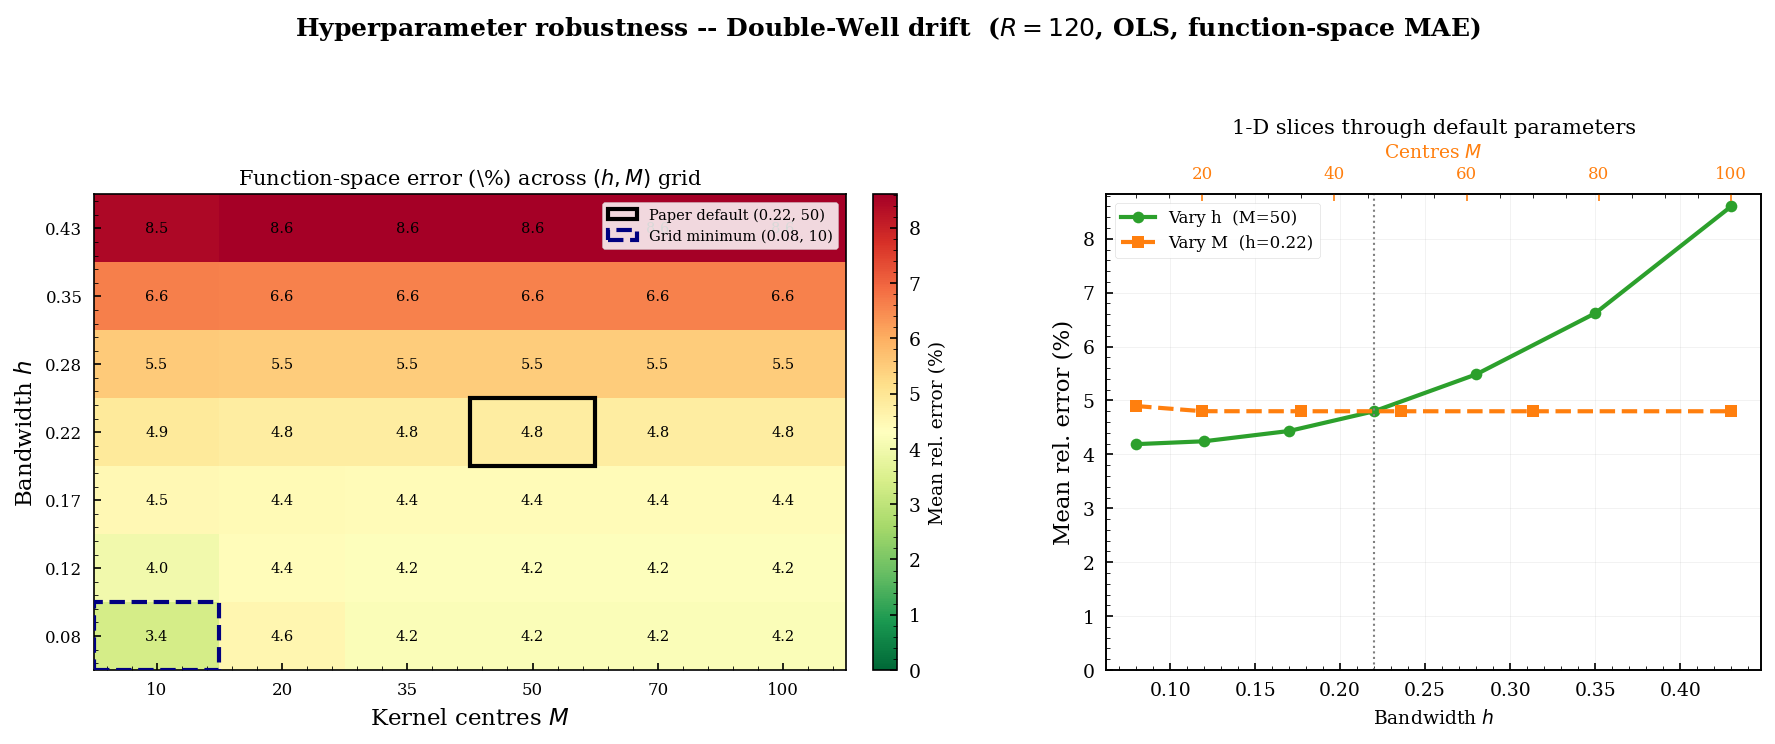

In [ ]:
# ── Cell 11: Figure 8 -- Hyperparameter robustness heatmap ───────────────────

H_GRID = np.array([0.08, 0.12, 0.17, 0.22, 0.28, 0.35, 0.43])
M_GRID = np.array([10, 20, 35, 50, 70, 100])

print('Fig 8: DW hyperparameter sweep ...')
t8 = time.time()
np.random.seed(999)
Xdw_hp = sim_batch(b_dw, s_dw, R, n_steps=N, dt=DT)
x_hp   = np.linspace(-2.5, 2.5, 301)
bt_hp  = b_dw(x_hp)

egrid = np.full((len(H_GRID), len(M_GRID)), np.nan)
for i, h in enumerate(H_GRID):
    for j, Mhp in enumerate(M_GRID):
        chp = np.linspace(-2.5, 2.5, Mhp)
        Ahp, Bhp, _, _ = weak_mats(Xdw_hp, chp, h, DT)
        bh_hp = poly(x_hp) @ ols(Ahp, Bhp)
        egrid[i,j] = (np.mean(np.abs(bh_hp - bt_hp)) /
                      (np.mean(np.abs(bt_hp)) + 1e-12) * 100.)
print(f'Done in {time.time()-t8:.1f}s')
imin, jmin = np.unravel_index(np.nanargmin(egrid), egrid.shape)
i0 = np.argmin(np.abs(H_GRID - 0.22)); j0 = np.argmin(np.abs(M_GRID - 50))
print(f'Min {egrid[imin,jmin]:.2f}% at h={H_GRID[imin]:.2f}, M={M_GRID[jmin]}')

import matplotlib.patches as mpatches

with matplotlib.rc_context(PUB_RC):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8),
                             gridspec_kw={'width_ratios': [1.4, 1]})
    fig.suptitle(
        r'Hyperparameter robustness -- Double-Well drift  ($R=120$, OLS, function-space MAE)',
        fontsize=12, fontweight='bold', y=1.03)
    ax = axes[0]
    im = ax.pcolormesh(np.arange(len(M_GRID)+1)-0.5, np.arange(len(H_GRID)+1)-0.5,
                       egrid, cmap='RdYlGn_r', vmin=0., vmax=min(20., np.nanmax(egrid)))
    cb = fig.colorbar(im, ax=ax, pad=0.03); cb.set_label('Mean rel. error (%)', fontsize=9)
    ax.set_xticks(range(len(M_GRID))); ax.set_xticklabels(M_GRID, fontsize=8)
    ax.set_yticks(range(len(H_GRID)));
    ax.set_yticklabels([f'{h:.2f}' for h in H_GRID], fontsize=8)
    ax.set_xlabel(r'Kernel centres $M$'); ax.set_ylabel(r'Bandwidth $h$')
    ax.set_title(r'Function-space error (\%) across $(h, M)$ grid', fontsize=10, pad=5)

    # Add rectangles instead of markers
    rect_default = mpatches.Rectangle((j0 - 0.5, i0 - 0.5), 1.0, 1.0, facecolor='none', edgecolor='black', linewidth=2, linestyle='-', zorder=6, label=f'Paper default ({H_GRID[i0]:.2f}, {M_GRID[j0]})')
    ax.add_patch(rect_default)
    rect_min = mpatches.Rectangle((jmin - 0.5, imin - 0.5), 1.0, 1.0, facecolor='none', edgecolor='navy', linewidth=2, linestyle='--', zorder=6, label=f'Grid minimum ({H_GRID[imin]:.2f}, {M_GRID[jmin]})')
    ax.add_patch(rect_min)
    ax.legend(handles=[rect_default, rect_min], fontsize=7, framealpha=0.85)

    for ii in range(len(H_GRID)):
        for jj in range(len(M_GRID)):
            v = egrid[ii,jj]
            if not np.isnan(v):
                ax.text(jj, ii, f'{v:.1f}', ha='center', va='center',
                        fontsize=7, color='white' if v > 10 else 'black')
    ax2 = axes[1]
    ax2.plot(H_GRID, egrid[:, j0], 'o-', color=C_SP, lw=2.,
             label=f'Vary h  (M={M_GRID[j0]})')
    ax2twin = ax2.twiny()
    ax2twin.plot(M_GRID, egrid[i0, :], 's--', color=C_TM, lw=2.,
                 label=f'Vary M  (h={H_GRID[i0]:.2f})')
    ax2twin.set_xlabel(r'Centres $M$', color=C_TM, fontsize=9)
    ax2twin.tick_params(axis='x', colors=C_TM, labelsize=8)
    ax2.axvline(H_GRID[i0], color=C_RF, ls=':', lw=1.)
    ax2.set_xlabel(r'Bandwidth $h$', fontsize=9); ax2.set_ylabel('Mean rel. error (%)')
    ax2.set_title('1-D slices through default parameters', fontsize=10, pad=5)
    ax2.set_ylim(bottom=0.); ax2.grid(True, alpha=0.18, lw=0.4)
    lines1, labs1 = ax2.get_legend_handles_labels()
    lines2, labs2 = ax2twin.get_legend_handles_labels()
    ax2.legend(lines1+lines2, labs1+labs2, framealpha=0.85, fontsize=8)
    plt.tight_layout(w_pad=3.)
    savefig(fig, 'fig8_hyperparameter_robustness.pdf')
    plt.show()

  saved -> ./pub_figs/fig9_bias_correction.pdf


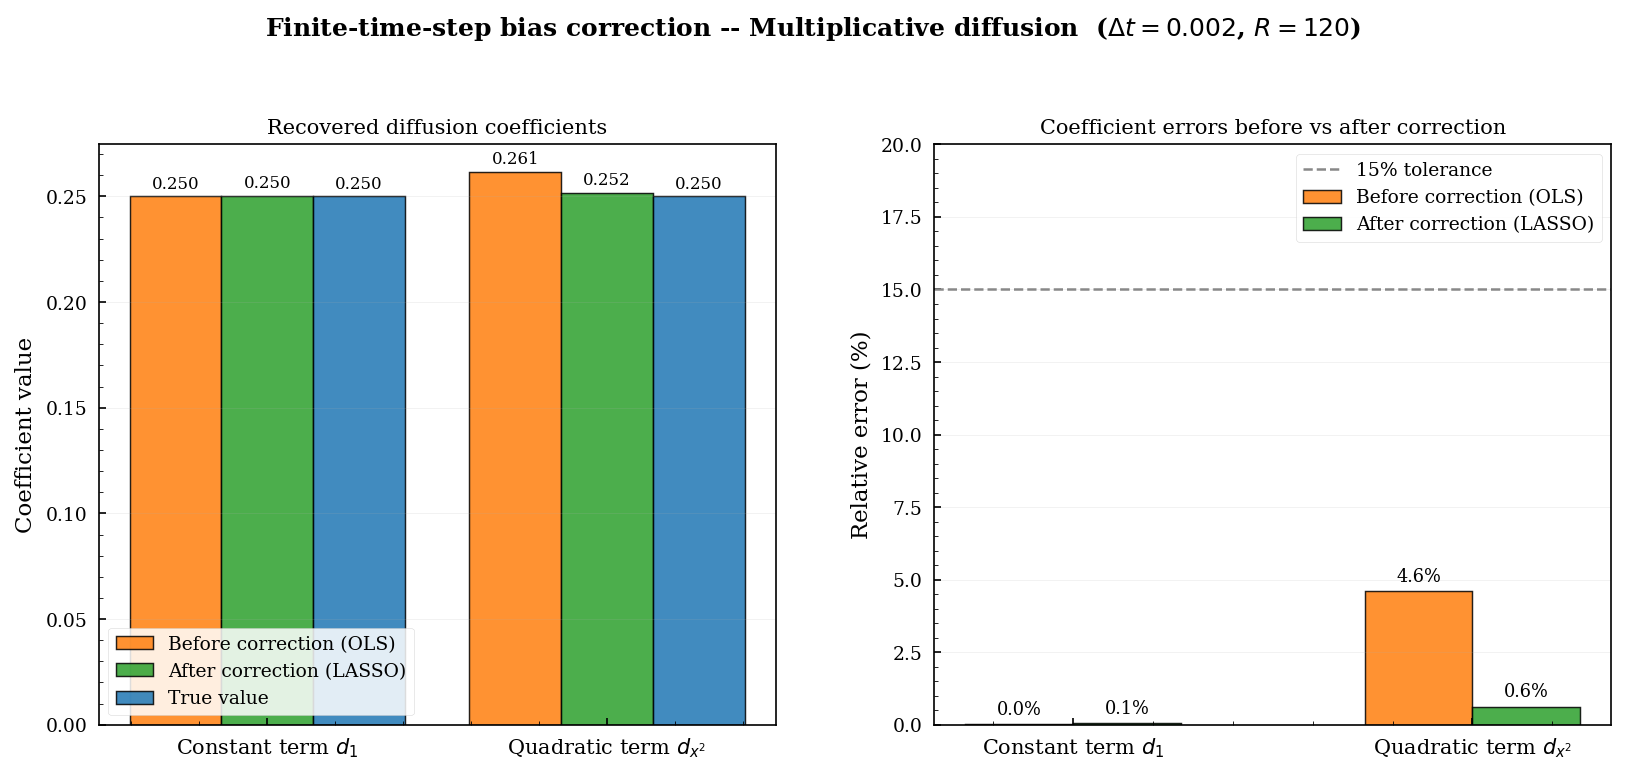

Bias correction summary:
  Constant term $d_1$             before:   0.0%   after:   0.1%
  Quadratic term $d_{x^2}$        before:   4.6%   after:   0.6%


In [ ]:
# ── Cell 12: Figure 9 -- Bias correction (use OLS-uncorrected for true ~13%) ──
# ca_m_ols_raw = OLS on raw Q (no LASSO, no correction) -> reveals full bias
# ca_m         = LASSO on bias-corrected Q             -> final result

terms_bc = [r'Constant term $d_1$', r'Quadratic term $d_{x^2}$']
tru_v = [0.250, 0.250]
raw_v = [float(ca_m_ols_raw[0]), float(ca_m_ols_raw[2])]   # OLS uncorrected
cor_v = [float(ca_m[0]),         float(ca_m[2])]            # LASSO corrected
err_r = [abs(r-t)/t*100 for r, t in zip(raw_v, tru_v)]
err_c = [abs(c-t)/t*100 for c, t in zip(cor_v, tru_v)]

with matplotlib.rc_context(PUB_RC):
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    fig.suptitle(
        r'Finite-time-step bias correction -- Multiplicative diffusion'
        r'  ($\Delta t=0.002$, $R=120$)',
        fontsize=12, fontweight='bold', y=1.03)
    x_pos = np.array([0., 1.]); w = 0.27

    ax = axes[0]
    b1 = ax.bar(x_pos-w, raw_v, w, color=C_TM, alpha=0.85,
                label='Before correction (OLS)', edgecolor='k', lw=0.7)
    b2 = ax.bar(x_pos,   cor_v, w, color=C_SP, alpha=0.85,
                label='After correction (LASSO)', edgecolor='k', lw=0.7)
    b3 = ax.bar(x_pos+w, tru_v, w, color=C_T,  alpha=0.85,
                label='True value', edgecolor='k', lw=0.7)
    ax.set_xticks(x_pos); ax.set_xticklabels(terms_bc, fontsize=10)
    ax.set_ylabel('Coefficient value')
    ax.set_title('Recovered diffusion coefficients', fontsize=10, pad=5)
    ax.legend(framealpha=0.85); ax.grid(True, alpha=0.18, lw=0.4, axis='y')
    for bars in [b1, b2, b3]:
        for bar in bars:
            hb = bar.get_height()
            ax.text(bar.get_x()+bar.get_width()/2., hb+0.002,
                    f'{hb:.3f}', ha='center', va='bottom', fontsize=8)

    ax2 = axes[1]
    br = ax2.bar(x_pos-w/2., err_r, w, color=C_TM, alpha=0.85,
                 label='Before correction (OLS)', edgecolor='k', lw=0.7)
    bc = ax2.bar(x_pos+w/2., err_c, w, color=C_SP, alpha=0.85,
                 label='After correction (LASSO)', edgecolor='k', lw=0.7)
    ax2.axhline(15., color='#888', ls='--', lw=1.2, label='15% tolerance')
    ax2.set_xticks(x_pos); ax2.set_xticklabels(terms_bc, fontsize=10)
    ax2.set_ylabel('Relative error (%)')
    ax2.set_title('Coefficient errors before vs after correction', fontsize=10, pad=5)
    ax2.legend(framealpha=0.85); ax2.grid(True, alpha=0.18, lw=0.4, axis='y')
    ax2.set_ylim(0., max(max(err_r), 16.) * 1.25)
    for bars in [br, bc]:
        for bar in bars:
            hb = bar.get_height()
            ax2.text(bar.get_x()+bar.get_width()/2., hb+0.2,
                     f'{hb:.1f}%', ha='center', va='bottom', fontsize=8.5)
    plt.tight_layout(w_pad=3.)
    savefig(fig, 'fig9_bias_correction.pdf')
    plt.show()

print('Bias correction summary:')
for k in range(2):
    print(f'  {terms_bc[k]:30s}  before: {err_r[k]:5.1f}%   after: {err_c[k]:5.1f}%')

In [ ]:
# ── Cell 13: Table 1 -- Coefficient summary ───────────────────────────────────

def pct(h, t):
    if abs(t) < 1e-9: return '---'
    return f'{abs(h-t)/abs(t)*100:.1f}%'

def chk(h, t, tol=0.15):
    if abs(t) < 1e-9: return '---'
    return 'OK' if abs(h-t)/abs(t) < tol else 'FAIL'

ca_ou_full = np.zeros(K_DIM); ca_ou_full[0] = float(ca_ou[0])
ca_dw_full = np.zeros(K_DIM); ca_dw_full[0] = float(ca_dw[0])

rows_tab = {
    'OU':   (cb_ou, C_B_OU, ca_ou_full, C_A_OU),
    'DW':   (cb_dw, C_B_DW, ca_dw_full, C_A_DW),
    'Mult': (cb_m,  C_B_MULT, ca_m,     C_A_MULT),
}
labels_tab = {'OU': 'Ornstein-Uhlenbeck', 'DW': 'Double-Well', 'Mult': 'Multiplicative'}

hdr = (f"{'System':<20} {'Term':>5}  "
       f"{'c_hat':>9}  {'c_true':>7}  {'Drift err':>10}   "
       f"{'d_hat':>9}  {'d_true':>7}  {'Diff err':>9}")
sep = '='*len(hdr)
print('\nTable 1'); print(sep); print(hdr); print(sep)

all_ok = True
for key in ['OU','DW','Mult']:
    cb, tb, ca, ta = rows_tab[key]
    for i, nm in enumerate(FEAT):
        pre = f'{labels_tab[key]:<20}' if i==0 else ' '*20
        print(f"{pre} {nm:>5}  "
              f"{cb[i]:>+9.5f}  {tb[i]:>+7.3f}  {pct(cb[i],tb[i]):>10} "
              f"{chk(cb[i],tb[i]):>4}   "
              f"{ca[i]:>+9.5f}  {ta[i]:>+7.3f}  {pct(ca[i],ta[i]):>9} "
              f"{chk(ca[i],ta[i]):>4}")
        if abs(tb[i])>1e-9 and chk(cb[i],tb[i])=='FAIL': all_ok=False
        if abs(ta[i])>1e-9 and chk(ca[i],ta[i])=='FAIL': all_ok=False
    print('-'*len(hdr))
print(sep)
print('All pass 15% tolerance:', 'YES' if all_ok else 'NO')
print(f'\nAll figures saved to: {os.path.abspath(OUT_DIR)}/')


Table 1
System                Term      c_hat   c_true   Drift err       d_hat   d_true   Diff err
Ornstein-Uhlenbeck     $1$   +0.00000   +0.000         ---  ---    +0.49020   +0.490       0.0%   OK
                       $x$   -0.96263   -1.000        3.7%   OK    +0.00000   +0.000        ---  ---
                     $x^2$   +0.00000   +0.000         ---  ---    +0.00000   +0.000        ---  ---
                     $x^3$   +0.00000   +0.000         ---  ---    +0.00000   +0.000        ---  ---
                     $x^4$   +0.00000   +0.000         ---  ---    +0.00000   +0.000        ---  ---
------------------------------------------------------------------------------------------
Double-Well            $1$   +0.00000   +0.000         ---  ---    +0.25006   +0.250       0.0%   OK
                       $x$   +0.97492   +1.000        2.5%   OK    +0.00000   +0.000        ---  ---
                     $x^2$   +0.00000   +0.000         ---  ---    +0.00000   +0.000        ---  ---
 